# Oppimisprojekti 3, osa 1: tekstigeneraattori transformerilla

Tässä notebookissa koulutetaan pieni decoder-tyyppinen transformer-malli tuottamaan Kalevalan tyylistä tekstiä. Tavoitteena on ymmärtää käytännössä, miten transformer oppii tekstiaineistosta seuraavan tokenin ennustamista.

**Tekoälyn käyttö:** Tekoälyä käytettiin apuna notebookin rakenteen suunnittelussa, koodin virheiden korjaamisessa ja raporttitekstin muotoilussa.


## Raportti

### Valittu tekstiaineisto

Aineistona käytettiin `kalevala_puhdas.txt`-tiedostoa. Tiedoston koko on noin 591 kt, joten se täyttää tehtävän vähintään 100 kt vaatimuksen. Kalevala on hyvä valinta, koska se on tekijänoikeuksista vapaa suomenkielinen klassikko, jonka tyyli on selvästi tunnistettava: runomitta, toistuvat henkilönimet ja vanhahtava sanasto näkyvät mallin tuottamassa tekstissä.

### Mallin rakenne ja tulokset

Notebookissa käytettiin decoder-only transformer -mallia kahdella asetuksella. Ensin koulutettiin nopea `fast`-malli ja sen jälkeen suurempi `quality`-malli, jotta nopeuden ja laadun ero näkyy käytännössä.

| Ominaisuus | `fast` | `quality` |
|---|---:|---:|
| Tokenisointi | SentencePiece BPE | SentencePiece BPE |
| Sanaston koko | 4000 | 4000 |
| Sekvenssin pituus | 64 tokenia | 64 tokenia |
| Embedding-koko | 96 | 192 |
| Attention-päitä | 3 | 4 |
| Transformer-blokkeja | 2 | 4 |
| Feed-forward-koko | 192 | 384 |
| Parametreja | 921 568 | 2 728 096 |
| Koulutus | 3 epochia | 5 epochia |
| Koulutusaika | 16.1 min | 29.2 min |
| Validointiloss | 3.60 | 0.39 |
| Validointiaccuracy | 0.27 | 0.92 |

`fast`-malli oppi Kalevalan sanastoa ja rytmiä, mutta teksti jäi usein katkonaiseksi. `quality`-malli oli noin 3.0 kertaa suurempi ja hitaampi kouluttaa, mutta validointitulos parani selvästi: loss pieneni noin arvosta 3.60 arvoon 0.39 ja accuracy nousi noin arvosta 0.27 arvoon 0.92. Tämä tukee tehtävänannon havaintoa siitä, että suurempi malli pystyy oppimaan aineiston rakenteita paremmin, mutta maksaa enemmän koulutusajassa ja muistinkulutuksessa.

### Generoidut esimerkit

Alla on lyhyt ote viimeisimmän ajon tuloksista. Koko taulukko näkyy alempana notebookin outputeissa ja tiedostossa `osa1_generoidut_esimerkit.csv`.

| Malli | Aloitusteksti | Lämpötila | Generoitu ote |
|---|---|---:|---|
| `fast` | Vaka vanha Väinämöinen | 0.8 | Vaka vanha Väinämöinen. Kysyi seppo Ilmarinen, saaren manterella, lylittamahan, jotta säilällä, käärmehisen. Kysytteli, kantoi aaltojen syvien kultakannen kaivonylmilkevän; olipoa noita itse... |
| `quality` | Vaka vanha Väinämöinen | 0.8 | Vaka vanha Väinämöinen, kylitse noita kuohumitseviperähän iäkseni. Niin sanovi Lemminkäinen, Kalevatar, kaunis impi, hänpä neittä neuvomahan, orpoa opastamahan, miten olla mielevänä, kuten k... |
| `fast` | Pohjan neito | 1.3 | Pohjan neitottama pystyyisin pauat, kahen kattiloissa, kaulan karehesti kultaiksen on aiaipi mättähällevina reisin;äsneljättä runooissa. Sai kaaren sortajaksi, lähtemästä pääs Untoa rukka, s... |
| `quality` | Pohjan neito | 1.3 | Pohjan neitotoavi. Sanoi vanha: "onsa keralla, hope'ita lähenki, kulkkinen suota, saoin päitä seipähissä; kiellyt, hiemmin laitehelle, taikin lattialle kaplauat, kesken katmusta!" Kullervo,... |

Pienellä lämpötilalla mallit pysyvät lähempänä Kalevalan sanastoa, mutta toistavat helposti tuttuja rakenteita. Suurella lämpötilalla teksti muuttuu luovemmaksi ja yllätyksellisemmäksi, mutta myös virheelliset sanamuodot ja katkonaiset lauserakenteet lisääntyvät. `quality`-malli säilyttää tyyliä paremmin kuin `fast`, vaikka sekään ei vielä tuota täysin luonnollista Kalevala-tekstiä.

### Havainnot lämpötila-arvoista

Pienellä lämpötilalla, esimerkiksi `0.4`, teksti on varovaisempaa ja toisteisempää. Se pysyy paremmin Kalevalan sanastossa, mutta alkaa helposti kierrättää samoja ilmauksia. Keskitasolla `0.8` ja `1.0` tulos on vaihtelevampaa: mukana on selvästi Kalevalan tyyliä, mutta myös rikkonaisia tai outoja sanayhdistelmiä. Suurella lämpötilalla `1.3` teksti muuttuu luovemmaksi ja sekavammaksi, jolloin sanojen taivutus ja lauserakenne hajoavat useammin.

### Hyperparametrien vaikutus

Mallivertailussa `fast`-asetus kouluttui noin 16.1 minuutissa ja `quality` noin 29.2 minuutissa. `fast` käytti pienempää embedding-kokoa ja kahta transformer-blokkia, joten se oli nopeampi mutta sen validointiloss jäi korkeammaksi. `quality` kasvatti embedding-koon 192:een ja transformer-blokkien määrän neljään. Parametrimäärä kasvoi 921 568 parametrista 2 728 096 parametriin, mutta validointiloss parani noin arvosta 3.60 arvoon 0.39. Tämä näyttää konkreettisesti nopeus-laatu-vaihtokaupan: suurempi malli oppii aineiston paremmin, mutta koulutus kestää pidempään.

### Miksi transformer-mallin kouluttaminen alusta alkaen on hidasta?

Alusta koulutettu malli ei tiedä valmiiksi mitään suomen kielestä, Kalevalan sanastosta tai tekstin rakenteesta. Se joutuu oppimaan kaiken tokenien välisistä tilastollisista suhteista. Transformerissa attention vertaa sekvenssin tokeneita toisiinsa, joten pidempi konteksti lisää laskentaa. Lisäksi suurempi sanasto, suuremmat embeddingit ja useammat kerrokset kasvattavat parametrimäärää nopeasti. Esikoulutetut mallit ovat arvokkaita juuri siksi, että yleinen kielitaito on opittu etukäteen paljon suuremmalla aineistolla ja laskentateholla.

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
import keras
from keras import layers

np.random.seed(42)
print("Keras:", keras.__version__)
print("Backend:", keras.config.backend())

Keras: 3.14.1
Backend: tensorflow


In [2]:
DATA_PATH = Path("kalevala_puhdas.txt")
assert DATA_PATH.exists(), f"Tiedostoa ei löydy: {DATA_PATH.resolve()}"

text = DATA_PATH.read_text(encoding="utf-8-sig")
print(f"Merkkejä: {len(text):,}")
print(f"Tavuja: {DATA_PATH.stat().st_size:,}")
print(text[:500])

Merkkejä: 545,594
Tavuja: 590,912
Ensimmäinen runo


Mieleni minun tekevi,
aivoni ajattelevi
lähteäni laulamahan,
saa'ani sanelemahan,
sukuvirttä suoltamahan,
lajivirttä laulamahan.
Sanat suussani sulavat,
puhe'et putoelevat,
kielelleni kerkiävät,
hampahilleni hajoovat.
Veli kulta, veikkoseni,
kaunis kasvinkumppalini!
Lähe nyt kanssa laulamahan,
saa kera sanelemahan
yhtehen yhyttyämme,
kahta'alta käytyämme!
Harvoin yhtehen yhymme,
saamme toinen toisihimme
näillä raukoilla rajoilla,
poloisilla Pohjan mailla.
Lyökämme käsi kätehen


## Tokenisointi

Käytän SentencePiece BPE -tokenisointia. Se jakaa sanat osiin, jolloin malli pystyy käsittelemään myös harvinaisia suomen taivutusmuotoja ilman valtavaa sanastoa.

In [3]:
VOCAB_SIZE = 4000
MODEL_PREFIX = "kalevala_sp_project"
TOKENIZER_MODEL = Path(f"{MODEL_PREFIX}.model")

if not TOKENIZER_MODEL.exists():
    tmp = Path("kalevala_sentencepiece_input.txt")
    tmp.write_text(text, encoding="utf-8")
    spm.SentencePieceTrainer.train(
        input=str(tmp),
        model_prefix=MODEL_PREFIX,
        vocab_size=VOCAB_SIZE,
        character_coverage=1.0,
        model_type="bpe",
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
    )

sp = spm.SentencePieceProcessor()
sp.load(str(TOKENIZER_MODEL))
print("Sanaston koko:", sp.get_piece_size())
print(sp.encode_as_pieces("Vaka vanha Väinämöinen"))

Sanaston koko: 4000
['▁Vaka', '▁vanha', '▁Väinämöinen']


In [4]:
SEQ_LENGTH = 64
STRIDE = 2
MAX_SEQUENCES = 60000

ids = np.array(sp.encode_as_ids(text), dtype=np.int32)
print("Tokeneita:", len(ids))

windows = []
for start in range(0, len(ids) - SEQ_LENGTH - 1, STRIDE):
    windows.append(ids[start:start + SEQ_LENGTH + 1])
    if MAX_SEQUENCES and len(windows) >= MAX_SEQUENCES:
        break

windows = np.array(windows, dtype=np.int32)
inputs = windows[:, :-1]
targets = windows[:, 1:]

rng = np.random.default_rng(42)
indices = rng.permutation(len(inputs))
split = int(0.85 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_inputs, train_targets = inputs[train_idx], targets[train_idx]
val_inputs, val_targets = inputs[val_idx], targets[val_idx]

print("Opetusdata:", train_inputs.shape, train_targets.shape)
print("Validointi:", val_inputs.shape, val_targets.shape)

Tokeneita: 144826
Opetusdata: (51000, 64) (51000, 64)
Validointi: (9000, 64) (9000, 64)


## Malli

Malli on decoder-only transformer: se näkee vain aiemmat tokenit causal maskin avulla. Tämä vastaa tekstigeneraattorin perusideaa, jossa seuraava token ennustetaan aiemman kontekstin perusteella.

In [5]:
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1, name="block"):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
        name=f"{name}_attention",
    )(x, x, use_causal_mask=True)
    x = layers.Add(name=f"{name}_attn_residual")([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_attn_norm")(x)

    ff = keras.Sequential([
        layers.Dense(ff_dim, activation="gelu"),
        layers.Dropout(dropout),
        layers.Dense(embed_dim),
    ], name=f"{name}_ffn")(x)
    x = layers.Add(name=f"{name}_ffn_residual")([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ffn_norm")(x)
    return x


def build_model(vocab_size, seq_length, embed_dim=128, num_heads=4, num_layers=2, ff_dim=256, dropout=0.1):
    token_ids = keras.Input(shape=(seq_length,), dtype="int32", name="token_ids")
    positions = keras.ops.expand_dims(keras.ops.arange(0, seq_length), axis=0)

    token_embedding = layers.Embedding(vocab_size, embed_dim, name="token_embedding")(token_ids)
    position_embedding = layers.Embedding(seq_length, embed_dim, name="position_embedding")(positions)
    x = layers.Add(name="token_plus_position")([token_embedding, position_embedding])
    x = layers.Dropout(dropout)(x)

    for i in range(num_layers):
        x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout, name=f"block_{i+1}")

    logits = layers.Dense(vocab_size, name="token_logits")(x)
    model = keras.Model(token_ids, logits, name="kalevala_decoder_transformer")
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model

configs = {
    "fast": dict(embed_dim=96, num_heads=3, num_layers=2, ff_dim=192, dropout=0.1, batch_size=64, epochs=3),
    "quality": dict(embed_dim=192, num_heads=4, num_layers=4, ff_dim=384, dropout=0.1, batch_size=48, epochs=5),
}

ACTIVE_CONFIG = "fast"
params = configs[ACTIVE_CONFIG]
model = build_model(sp.get_piece_size(), SEQ_LENGTH, **{k: params[k] for k in ["embed_dim", "num_heads", "num_layers", "ff_dim", "dropout"]})
model.summary()
print("Parametreja yhteensä:", f"{model.count_params():,}")

Model: "kalevala_decoder_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 64, 96)    │    384,000 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_plus_position │ (1, 64, 96)       │          0 │ token_embedding[… │
│ (Add)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (1, 64, 96)       │          0 │ token_plus_posit… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attention   │ (1, 64, 96)       │     37,248 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attn_resid… │ (1, 64, 96)       │          0 │ dropout[0][0],    │
│ (Add)               │                   │            │ block_1_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attn_norm   │ (1, 64, 96)       │        192 │ block_1_attn_res… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ffn         │ (1, 64, 96)       │     37,152 │ block_1_attn_nor… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ffn_residu… │ (1, 64, 96)       │          0 │ block_1_attn_nor… │
│ (Add)               │                   │            │ block_1_ffn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ffn_norm    │ (1, 64, 96)       │        192 │ block_1_ffn_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attention   │ (1, 64, 96)       │     37,248 │ block_1_ffn_norm… │
│ (MultiHeadAttentio… │                   │            │ block_1_ffn_norm… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attn_resid… │ (1, 64, 96)       │          0 │ block_1_ffn_norm… │
│ (Add)               │                   │            │ block_2_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attn_norm   │ (1, 64, 96)       │        192 │ block_2_attn_res… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ffn         │ (1, 64, 96)       │     37,152 │ block_2_attn_nor… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ffn_residu… │ (1, 64, 96)       │          0 │ block_2_attn_nor… │
│ (Add)               │                   │            │ block_2_ffn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ffn_norm    │ (1, 64, 96)       │        192 │ block_2_ffn_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_logits        │ (1, 64, 4000)     │    388,000 │ block_2_ffn_norm… │
│ (Dense)             │                   │            │                 

 Total params: 921,568 (3.52 MB)

 Trainable params: 921,568 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

Parametreja yhteensä: 921,568


In [6]:
start_time = time.perf_counter()
history = model.fit(
    train_inputs,
    train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=params["batch_size"],
    epochs=params["epochs"],
)
training_seconds = time.perf_counter() - start_time
print(f"Koulutusaika: {training_seconds:.1f} s")

Epoch 1/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 361s 408ms/step - accuracy: 0.1570 - loss: 6.0369 - val_accuracy: 0.2094 - val_loss: 4.9430
Epoch 2/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 293s 367ms/step - accuracy: 0.2189 - loss: 4.5472 - val_accuracy: 0.2358 - val_loss: 4.0773
Epoch 3/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 311s 390ms/step - accuracy: 0.2393 - loss: 3.9454 - val_accuracy: 0.2667 - val_loss: 3.5912
Koulutusaika: 965.0 s


,accuracy,loss,val_accuracy,val_loss,epoch
0,0.157009,6.036885,0.209373,4.942980,1
1,0.218945,4.547210,0.235835,4.077334,2
2,0.239331,3.945392,0.266741,3.591231,3


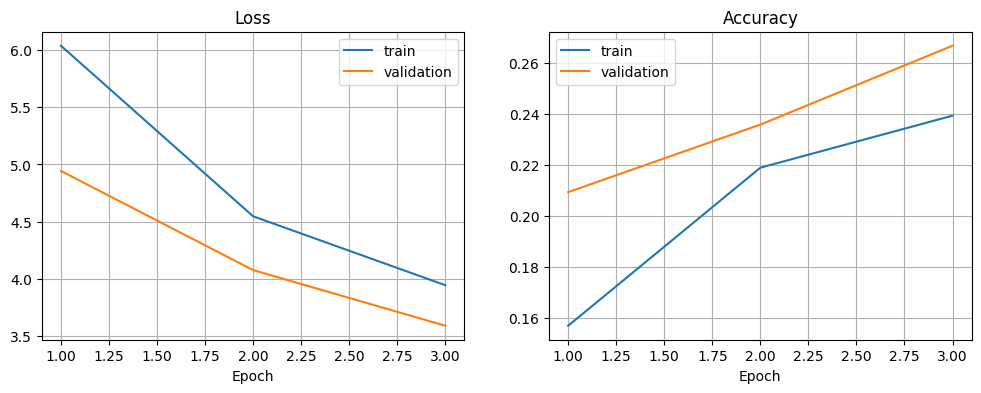

In [7]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)
display(history_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["accuracy"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].grid(True)
axes[1].legend()
plt.show()

## Tekstin generointi eri lämpötiloilla

Lämpötila muuttaa seuraavan tokenin todennäköisyysjakaumaa. Pieni arvo tekee tekstistä varovaisempaa ja toisteisempaa, suuri arvo luovempaa mutta myös sekavampaa.

In [8]:
def sample_from_logits(logits, temperature=1.0):
    temperature = max(float(temperature), 1e-5)
    logits = logits / temperature
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    probs = probs / probs.sum()
    return int(np.random.choice(len(probs), p=probs))


def generate_text(model, sp, prompt, num_tokens=120, temperature=1.0, seq_length=SEQ_LENGTH):
    context = sp.encode_as_ids(prompt)
    generated = list(context)

    for _ in range(num_tokens):
        window = generated[-seq_length:]
        if len(window) < seq_length:
            window = [sp.pad_id()] * (seq_length - len(window)) + window
        x = np.array([window], dtype=np.int32)
        logits = model.predict(x, verbose=0)[0, -1]
        next_id = sample_from_logits(logits, temperature)
        generated.append(next_id)

    return sp.decode(generated)

prompts = ["Vaka vanha Väinämöinen", "Mieleni minun tekevi", "Pohjan neito"]
temperatures = [0.4, 0.8, 1.0, 1.3]

rows = []
for prompt in prompts:
    for temp in temperatures:
        rows.append({
            "prompt": prompt,
            "temperature": temp,
            "generated_text": generate_text(model, sp, prompt, temperature=temp),
        })

generated_df = pd.DataFrame(rows)
display(generated_df)

,prompt,temperature,generated_text
0,Vaka vanha Väinämöinen,0.4,"Vaka vanha Väinämöinen, käeten, valettavan. Sa..."
1,Vaka vanha Väinämöinen,0.8,"Vaka vanha Väinämöinen. Kysyi seppo Ilmarinen,..."
2,Vaka vanha Väinämöinen,1.0,Vaka vanha Väinämöinen: panin tuhonnut ri korj...
3,Vaka vanha Väinämöinen,1.3,"Vaka vanha Väinämöinen nousevilla, somisilta t..."
4,Mieleni minun tekevi,0.4,"Mieleni minun tekevi, sivulla, alle. ""Jo vaine..."
5,Mieleni minun tekevi,0.8,"Mieleni minun tekevi, päivän, siivenillä, silm..."
6,Mieleni minun tekevi,1.0,"Mieleni minun tekevi. ""Kun eteltu, kun kävijäl..."
7,Mieleni minun tekevi,1.3,"Mieleni minun tekeviksi, lapsilunna.""ä manoill..."
8,Pohjan neito,0.4,"Pohjan neitoseksi, pääytän Manan maista, hope'..."
9,Pohjan neito,0.8,"Pohjan neitoseksi, porstu sulhosen, ishiset. E..."


In [9]:
MODEL_PATH = Path(f"kalevala_transformer_{ACTIVE_CONFIG}.keras")
model.save(MODEL_PATH)
print("Tallennettu:", MODEL_PATH.resolve())

Tallennettu: D:\Transformer-mallit\kalevala_transformer_fast.keras


## Mallikoon vertailu

Seuraava solu kuuluu samaan `Run All` -ajoon: se käyttää yläpuolella juuri koulutettua `fast`-mallia, ajaa heti perään suuremman `quality`-mallin ja muodostaa yhteisen vertailutaulukon. Solu kestää selvästi kauemmin kuin nopea malli. Ajon jälkeen syntyvät `osa1_mallivertailu.csv`, päivitetty `osa1_generoidut_esimerkit.csv` ja `kalevala_transformer_quality.keras`.

In [10]:
print("Mallivertailu alkaa: käytetään ensin saman ajon aikana koulutettua fast-mallia.")
fast_model = model
fast_eval = fast_model.evaluate(val_inputs[:2000], val_targets[:2000], batch_size=64)

fast_summary = {
    "config": "fast",
    "embed_dim": configs["fast"]["embed_dim"],
    "num_heads": configs["fast"]["num_heads"],
    "num_layers": configs["fast"]["num_layers"],
    "ff_dim": configs["fast"]["ff_dim"],
    "epochs": configs["fast"]["epochs"],
    "parameters": fast_model.count_params(),
    "training_seconds": training_seconds,
    "val_loss": fast_eval[0],
    "val_accuracy": fast_eval[1],
}

print("Fast-mallin yhteenveto")
display(pd.DataFrame([fast_summary]))

quality_params = configs["quality"]
quality_model = build_model(
    sp.get_piece_size(),
    SEQ_LENGTH,
    **{k: quality_params[k] for k in ["embed_dim", "num_heads", "num_layers", "ff_dim", "dropout"]},
)
print("Quality-mallin parametreja:", f"{quality_model.count_params():,}")

quality_start = time.perf_counter()
quality_history = quality_model.fit(
    train_inputs,
    train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=quality_params["batch_size"],
    epochs=quality_params["epochs"],
)
quality_training_seconds = time.perf_counter() - quality_start
print(f"Quality-mallin koulutusaika: {quality_training_seconds:.1f} s")

quality_history_df = pd.DataFrame(quality_history.history)
quality_history_df["epoch"] = np.arange(1, len(quality_history_df) + 1)
display(quality_history_df)

quality_eval = quality_model.evaluate(val_inputs[:2000], val_targets[:2000], batch_size=quality_params["batch_size"])
quality_summary = {
    "config": "quality",
    "embed_dim": quality_params["embed_dim"],
    "num_heads": quality_params["num_heads"],
    "num_layers": quality_params["num_layers"],
    "ff_dim": quality_params["ff_dim"],
    "epochs": quality_params["epochs"],
    "parameters": quality_model.count_params(),
    "training_seconds": quality_training_seconds,
    "val_loss": quality_eval[0],
    "val_accuracy": quality_eval[1],
}

comparison_df = pd.DataFrame([fast_summary, quality_summary])
display(comparison_df)
comparison_df.to_csv("osa1_mallivertailu.csv", index=False)

quality_rows = []
for prompt in prompts:
    for temp in temperatures:
        quality_rows.append({
            "prompt": prompt,
            "temperature": temp,
            "generated_text": generate_text(quality_model, sp, prompt, temperature=temp),
        })

quality_generated_df = pd.DataFrame(quality_rows)
display(quality_generated_df)

fast_generated_df = generated_df.copy()
fast_generated_df.insert(0, "config", "fast")
quality_generated_export = quality_generated_df.copy()
quality_generated_export.insert(0, "config", "quality")
all_generated_df = pd.concat([fast_generated_df, quality_generated_export], ignore_index=True)
all_generated_df.to_csv("osa1_generoidut_esimerkit.csv", index=False)

quality_model_path = Path("kalevala_transformer_quality.keras")
quality_model.save(quality_model_path)
print("Tallennettu:", quality_model_path.resolve())
print("Vertailutiedostot tallennettu: osa1_mallivertailu.csv ja osa1_generoidut_esimerkit.csv")


Mallivertailu alkaa: käytetään ensin saman ajon aikana koulutettua fast-mallia.
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.2655 - loss: 3.5994
Fast-mallin yhteenveto


,config,embed_dim,num_heads,num_layers,ff_dim,epochs,parameters,training_seconds,val_loss,val_accuracy
0,fast,96,3,2,192,3,921568,965.037927,3.59939,0.265469


Quality-mallin parametreja: 2,728,096
Epoch 1/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 370s 338ms/step - accuracy: 0.1961 - loss: 5.1841 - val_accuracy: 0.2661 - val_loss: 3.8354
Epoch 2/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 368s 347ms/step - accuracy: 0.3268 - loss: 3.3000 - val_accuracy: 0.4756 - val_loss: 2.3581
Epoch 3/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 335s 315ms/step - accuracy: 0.5124 - loss: 2.1374 - val_accuracy: 0.7212 - val_loss: 1.2369
Epoch 4/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 324s 305ms/step - accuracy: 0.6699 - loss: 1.3671 - val_accuracy: 0.8677 - val_loss: 0.6383
Epoch 5/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 355s 334ms/step - accuracy: 0.7703 - loss: 0.9305 - val_accuracy: 0.9212 - val_loss: 0.3901
Quality-mallin koulutusaika: 1752.3 s


,accuracy,loss,val_accuracy,val_loss,epoch
0,0.196074,5.184057,0.266059,3.835434,1
1,0.326780,3.299955,0.475550,2.358118,2
2,0.512355,2.137355,0.721222,1.236923,3
3,0.669866,1.367114,0.867679,0.638284,4
4,0.770335,0.930482,0.921240,0.390144,5


42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.9215 - loss: 0.3897


,config,embed_dim,num_heads,num_layers,ff_dim,epochs,parameters,training_seconds,val_loss,val_accuracy
0,fast,96,3,2,192,3,921568,965.037927,3.599390,0.265469
1,quality,192,4,4,384,5,2728096,1752.308969,0.389657,0.921516


,prompt,temperature,generated_text
0,Vaka vanha Väinämöinen,0.4,"Vaka vanha Väinämöinen, kylitse noita mielellä..."
1,Vaka vanha Väinämöinen,0.8,"Vaka vanha Väinämöinen, kylitse noita kuohumit..."
2,Vaka vanha Väinämöinen,1.0,"Vaka vanha Väinämöinen, ongelivat miehen viiel..."
3,Vaka vanha Väinämöinen,1.3,"Vaka vanha Väinämöinen: vesiä Ahistä laian, ah..."
4,Mieleni minun tekevi,0.4,"Mieleni minun tekevi, jalkoihin jaloihin, kalm..."
5,Mieleni minun tekevi,0.8,"Mieleni minun tekevi, varsi viittä sormukset s..."
6,Mieleni minun tekevi,1.0,"Mieleni minun tekevi, varsi viittä ikuiseksi. ..."
7,Mieleni minun tekevi,1.3,"Mieleni minun tekevi, sormukset päällensä. Sep..."
8,Pohjan neito,0.4,"Pohjan neito vastahansa, puihin. Sanoi vanha u..."
9,Pohjan neito,0.8,"Pohjan neito vastahansa, puihin. Sanoi tuolta ..."


Tallennettu: D:\Transformer-mallit\kalevala_transformer_quality.keras
Vertailutiedostot tallennettu: osa1_mallivertailu.csv ja osa1_generoidut_esimerkit.csv
